# Inbound Calls Per Extension — 13th-19th January

Analysis of inbound call handling across Hertz extensions.
- Which extensions answer the most/fewest calls?
- High-level call statistics
- Relationship between call duration and answer rate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Brand colours (visual-guide.md) ---
HERTZ_YELLOW = '#F5C400'
CHARCOAL = '#1A1A1A'
DARK_GRAY = '#6E6E6E'
LIGHT_GRAY = '#E6E6E6'
POS_GREEN = '#2E7D32'
NEG_RED = '#C62828'
TERTIARY = '#BDBDBD'

# --- Load data ---
raw = pd.read_excel(
    '../data/raw/InBound Calls Per Department 13th-19th Jan.xlsx',
    engine='openpyxl',
    header=1
)

df = raw[['Department', 'Received Calls', 'Answered Calls',
          'Unanswered Calls', 'Answered Calls Duration', 'ACD']].copy()

# Ensure numeric
for col in ['Received Calls', 'Answered Calls', 'Unanswered Calls', 'ACD']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Exclude -NONE- (central queue)
df = df[df['Department'] != '-NONE-'].copy()

# Derived metrics
df['pct_answered'] = (df['Answered Calls'] / df['Received Calls'] * 100).round(1)
df['pct_unanswered'] = (df['Unanswered Calls'] / df['Received Calls'] * 100).round(1)

# Filtered set (≥10 calls) for rankings
df_filtered = df[df['Received Calls'] >= 10].copy()

print(f'Total extensions (excl. NONE): {len(df):,}')
print(f'Extensions with ≥10 calls:     {len(df_filtered):,}')
print(f'Extensions excluded (<10):     {len(df) - len(df_filtered):,}')
df_filtered.head()

Total extensions (excl. NONE): 1,170
Extensions with ≥10 calls:     1,101
Extensions excluded (<10):     69


,Department,Received Calls,Answered Calls,Unanswered Calls,Answered Calls Duration,ACD,pct_answered,pct_unanswered
1,aaamacon492803,107,84,23,"4 H , 44.9 M",2.66,78.5,21.5
2,abbotsford805603,291,82,209,"3 H , 12.1 M",0.66,28.2,71.8
3,abbotsford809401,123,3,120,"0 H , 3.85 M",0.03,2.4,97.6
4,adamord743310,163,132,31,"5 H , 12.42 M",1.92,81.0,19.0
5,addiso769007,43,43,0,"2 H , 53.87 M",4.04,100.0,0.0


## 1. High-Level Statistics

In [2]:
total_received = df['Received Calls'].sum()
total_answered = df['Answered Calls'].sum()
total_unanswered = df['Unanswered Calls'].sum()
overall_pct = total_answered / total_received * 100

print('=' * 58)
print('  INBOUND CALL SUMMARY — 13-19 Jan (excl. NONE queue)')
print('=' * 58)
print(f'  Total extensions analysed:   {len(df):>8,}')
print(f'  Total received calls:        {total_received:>8,}')
print(f'  Total answered calls:        {total_answered:>8,}')
print(f'  Total unanswered calls:      {total_unanswered:>8,}')
print(f'  Overall % answered:          {overall_pct:>7.1f}%')
print(f'  Median extension % answered: {df_filtered["pct_answered"].median():>7.1f}%')
print(f'  Mean extension % answered:   {df_filtered["pct_answered"].mean():>7.1f}%')
print(f'  Avg ACD (minutes):           {df_filtered["ACD"].mean():>7.2f}')
print('=' * 58)

  INBOUND CALL SUMMARY — 13-19 Jan (excl. NONE queue)
  Total extensions analysed:      1,170
  Total received calls:         185,734
  Total answered calls:         112,623
  Total unanswered calls:        73,111
  Overall % answered:             60.6%
  Median extension % answered:    77.0%
  Mean extension % answered:      66.0%
  Avg ACD (minutes):              2.09


## 2. Top 10 Extensions — Highest % Answered

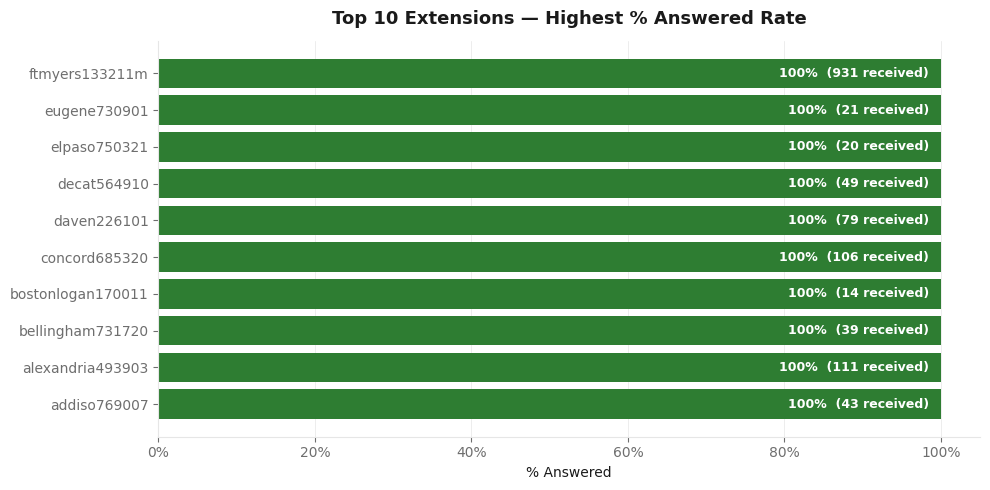

In [3]:
top10 = df_filtered.nlargest(10, 'pct_answered').sort_values('pct_answered')

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10['Department'], top10['pct_answered'], color=POS_GREEN)

# Labels on bars
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() - 1.5, bar.get_y() + bar.get_height() / 2,
            f'{row["pct_answered"]:.0f}%  ({int(row["Received Calls"])} received)',
            va='center', ha='right', fontsize=9, color='white', fontweight='bold')

ax.set_xlim(0, 105)
ax.set_xlabel('% Answered', color=CHARCOAL)
ax.set_title('Top 10 Extensions — Highest % Answered Rate',
             fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', color=LIGHT_GRAY, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
ax.tick_params(colors=DARK_GRAY)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

## 3. Bottom 10 Extensions — Lowest % Answered

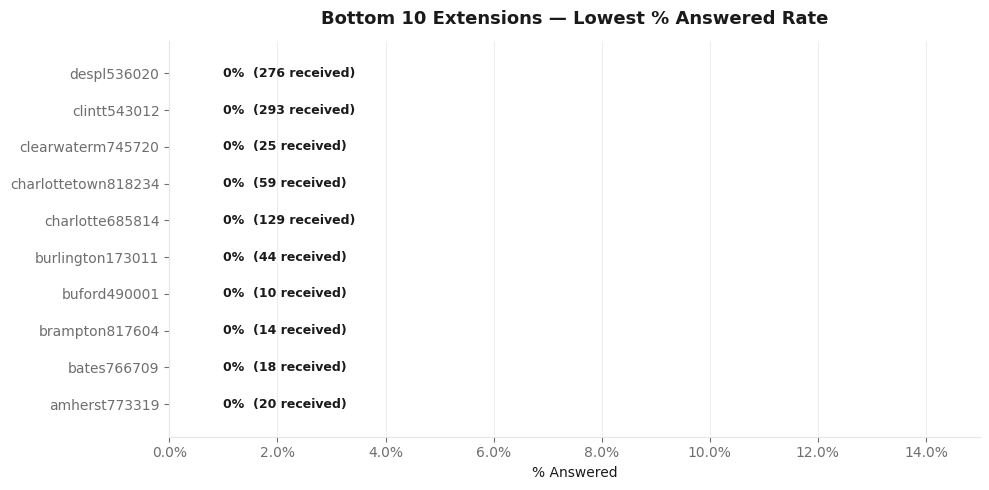

In [4]:
bottom10 = df_filtered.nsmallest(10, 'pct_answered').sort_values('pct_answered', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(bottom10['Department'], bottom10['pct_answered'], color=NEG_RED)

for bar, (_, row) in zip(bars, bottom10.iterrows()):
    x_pos = max(bar.get_width() + 0.5, 1)
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{row["pct_answered"]:.0f}%  ({int(row["Received Calls"])} received)',
            va='center', ha='left', fontsize=9, color=CHARCOAL, fontweight='bold')

ax.set_xlim(0, max(bottom10['pct_answered']) + 15)
ax.set_xlabel('% Answered', color=CHARCOAL)
ax.set_title('Bottom 10 Extensions — Lowest % Answered Rate',
             fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='x', color=LIGHT_GRAY, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
ax.tick_params(colors=DARK_GRAY)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

## 4. Distribution of % Answered Across All Extensions

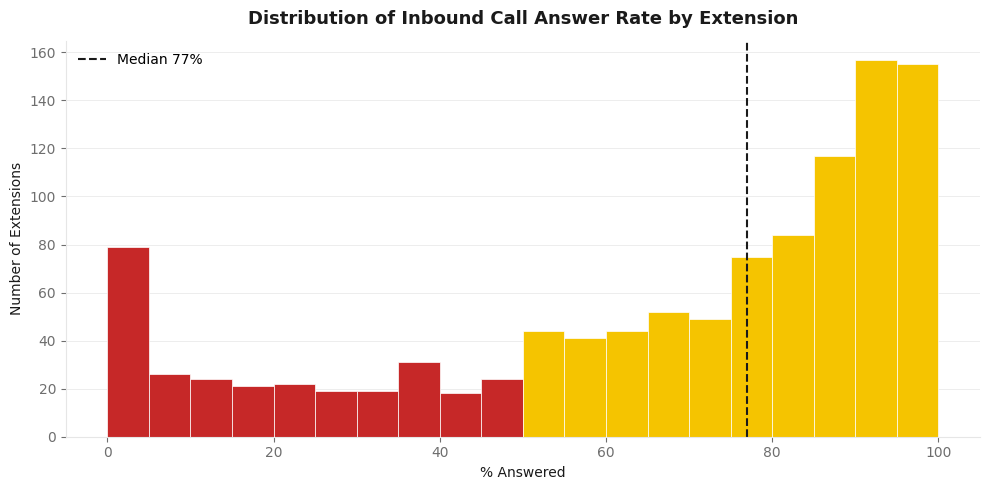


Extension count by answer-rate bucket:
pct_answered
0-25%      125
25-50%     116
50-75%     234
75-90%     273
90-100%    306


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.arange(0, 105, 5)
counts, edges, patches = ax.hist(df_filtered['pct_answered'], bins=bins,
                                  color=HERTZ_YELLOW, edgecolor='white', linewidth=0.5)

# Colour bars below 50% red
for patch, left_edge in zip(patches, edges[:-1]):
    if left_edge < 50:
        patch.set_facecolor(NEG_RED)

median_val = df_filtered['pct_answered'].median()
ax.axvline(median_val, color=CHARCOAL, linewidth=1.5, linestyle='--', label=f'Median {median_val:.0f}%')

ax.set_xlabel('% Answered', color=CHARCOAL)
ax.set_ylabel('Number of Extensions', color=CHARCOAL)
ax.set_title('Distribution of Inbound Call Answer Rate by Extension',
             fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)
ax.legend(frameon=False, fontsize=10)
ax.grid(axis='y', color=LIGHT_GRAY, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
ax.tick_params(colors=DARK_GRAY)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

# Quick bucket summary
print('\nExtension count by answer-rate bucket:')
buckets = pd.cut(df_filtered['pct_answered'],
                 bins=[0, 25, 50, 75, 90, 100],
                 labels=['0-25%', '25-50%', '50-75%', '75-90%', '90-100%'])
print(buckets.value_counts().sort_index().to_string())

## 5. Bubble Chart — ACD vs % Answered vs Call Volume

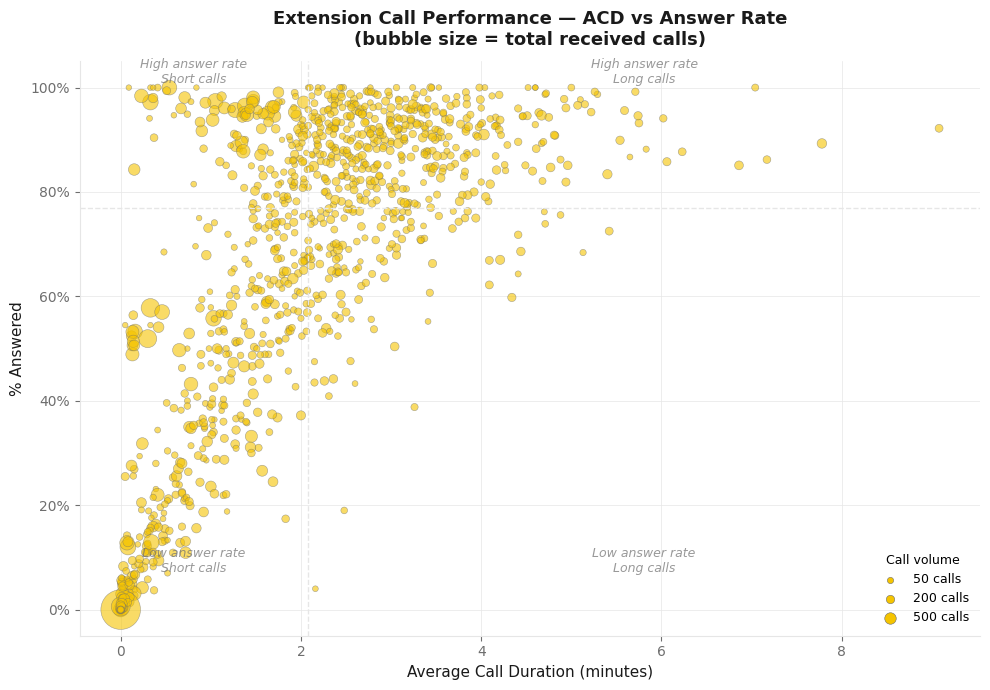

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))

sizes = df_filtered['Received Calls']
# Scale bubble sizes for visibility
size_scaled = (sizes / sizes.max()) * 800 + 15

scatter = ax.scatter(
    df_filtered['ACD'],
    df_filtered['pct_answered'],
    s=size_scaled,
    c=HERTZ_YELLOW,
    alpha=0.6,
    edgecolors=DARK_GRAY,
    linewidths=0.4
)

# Quadrant lines
med_acd = df_filtered['ACD'].median()
med_pct = df_filtered['pct_answered'].median()
ax.axhline(med_pct, color=LIGHT_GRAY, linewidth=1, linestyle='--')
ax.axvline(med_acd, color=LIGHT_GRAY, linewidth=1, linestyle='--')

# Quadrant labels
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
label_kw = dict(fontsize=9, color=DARK_GRAY, alpha=0.7, fontstyle='italic')
ax.text(med_acd + (x_max - med_acd) * 0.5, med_pct + (y_max - med_pct) * 0.85,
        'High answer rate\nLong calls', ha='center', **label_kw)
ax.text(med_acd - (med_acd - x_min) * 0.5, med_pct + (y_max - med_pct) * 0.85,
        'High answer rate\nShort calls', ha='center', **label_kw)
ax.text(med_acd - (med_acd - x_min) * 0.5, med_pct - (med_pct - y_min) * 0.85,
        'Low answer rate\nShort calls', ha='center', **label_kw)
ax.text(med_acd + (x_max - med_acd) * 0.5, med_pct - (med_pct - y_min) * 0.85,
        'Low answer rate\nLong calls', ha='center', **label_kw)

ax.set_xlabel('Average Call Duration (minutes)', color=CHARCOAL, fontsize=11)
ax.set_ylabel('% Answered', color=CHARCOAL, fontsize=11)
ax.set_title('Extension Call Performance — ACD vs Answer Rate\n(bubble size = total received calls)',
             fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis='both', color=LIGHT_GRAY, linewidth=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
ax.tick_params(colors=DARK_GRAY)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Size legend
for s_label, s_val in [(50, 50), (200, 200), (500, 500)]:
    ax.scatter([], [], s=(s_val / sizes.max()) * 800 + 15,
               c=HERTZ_YELLOW, edgecolors=DARK_GRAY, linewidths=0.4,
               label=f'{s_label} calls')
ax.legend(loc='lower right', frameon=False, fontsize=9, title='Call volume',
          title_fontsize=9)

plt.tight_layout()
plt.show()

## 6. Bimodal Distribution — Why the Spike at 0%?

The histogram shows two distinct modes:
- **Mode 1 (left spike):** ~79 extensions clustered at 0-5% answer rate
- **Mode 2 (right mass):** Extensions concentrated in the 85-100% range

This section investigates the left spike — are these truly underperforming extensions, or inactive/misconfigured ones?

In [7]:
# --- Profile the two modes ---
low_group = df_filtered[df_filtered['pct_answered'] < 5]
high_group = df_filtered[df_filtered['pct_answered'] >= 50]

zero_exact = df_filtered[df_filtered['pct_answered'] == 0]

print(f'Extensions with <5% answer rate:  {len(low_group)}')
print(f'  Of which exactly 0% answered:   {len(zero_exact)}')
print(f'  Total received calls (0% ext):  {zero_exact["Received Calls"].sum():,}')
print()

# Compare the two populations
print(f'{"Metric":<30s} {"<5% answered":>15s} {"≥50% answered":>15s}')
print('-' * 62)
print(f'{"Number of extensions":<30s} {len(low_group):>15,} {len(high_group):>15,}')
print(f'{"Total received calls":<30s} {low_group["Received Calls"].sum():>15,} {high_group["Received Calls"].sum():>15,}')
print(f'{"Median received calls":<30s} {low_group["Received Calls"].median():>15,.0f} {high_group["Received Calls"].median():>15,.0f}')
print(f'{"Mean ACD (minutes)":<30s} {low_group["ACD"].mean():>15.2f} {high_group["ACD"].mean():>15.2f}')
print(f'{"Median ACD (minutes)":<30s} {low_group["ACD"].median():>15.2f} {high_group["ACD"].median():>15.2f}')

Extensions with <5% answer rate:  79
  Of which exactly 0% answered:   47
  Total received calls (0% ext):  11,959

Metric                            <5% answered   ≥50% answered
--------------------------------------------------------------
Number of extensions                        79             818
Total received calls                    22,492         124,700
Median received calls                      125             116
Mean ACD (minutes)                        0.05            2.60
Median ACD (minutes)                      0.00            2.46


In [8]:
# --- Same location, different extensions: split personality ---
# Many 0% extensions share a location name with a healthy extension,
# suggesting the 0% extension is a secondary/unused line at the same branch.

df_filtered['base_name'] = df_filtered['Department'].str.replace(r'\d+$', '', regex=True)

# Find 0% extensions whose base name also has a >=50% sibling
zero_ext = df_filtered[df_filtered['pct_answered'] == 0].copy()
healthy_bases = set(df_filtered[df_filtered['pct_answered'] >= 50]['base_name'])
zero_ext['has_healthy_sibling'] = zero_ext['base_name'].isin(healthy_bases)

n_with = zero_ext['has_healthy_sibling'].sum()
n_without = len(zero_ext) - n_with

print(f'Of {len(zero_ext)} extensions with 0% answer rate:')
print(f'  {n_with} ({n_with/len(zero_ext)*100:.0f}%) share a location with a ≥50% sibling  → likely inactive/overflow line')
print(f'  {n_without} ({n_without/len(zero_ext)*100:.0f}%) have NO healthy sibling              → potentially genuinely unreachable')
print()

# Show examples of split-personality locations
print('Examples — same location, one extension answers, another does not:')
print(f'{"Extension":<35s} {"Received":>8s} {"Answered":>8s} {"% Ans":>7s} {"ACD":>5s}')
print('-' * 65)
for loc in ['houstonhobby', 'ftmyers', 'charlotte', 'woodbridge', 'abbotsford']:
    matches = df_filtered[df_filtered['base_name'].str.contains(loc, case=False, na=False)].sort_values('pct_answered')
    if len(matches) > 1:
        for _, r in matches.iterrows():
            flag = ' ◄' if r['pct_answered'] < 5 else ''
            print(f'{r["Department"]:<35s} {int(r["Received Calls"]):>8,} {int(r["Answered Calls"]):>8,} {r["pct_answered"]:>6.1f}% {r["ACD"]:>5.2f}{flag}')
        print()

Of 47 extensions with 0% answer rate:
  7 (15%) share a location with a ≥50% sibling  → likely inactive/overflow line
  40 (85%) have NO healthy sibling              → potentially genuinely unreachable

Examples — same location, one extension answers, another does not:
Extension                           Received Answered   % Ans   ACD
-----------------------------------------------------------------
houstonhobbydtg74336                   7,468        1    0.0%  0.00 ◄
houstonhobbyap160724                     536      526   98.1%  0.71

ftmyers747313                            149      138   92.6%  3.37
ftmyers133211m                           931      931  100.0%  0.54

charlotte685814                          129        0    0.0%  0.00 ◄
charlottetown818234                       59        0    0.0%  0.00 ◄
charlotteadmin188012                     878      468   53.3%  0.16
charlottesvill185303                      49       34   69.4%  1.26
charlotte685008                          185

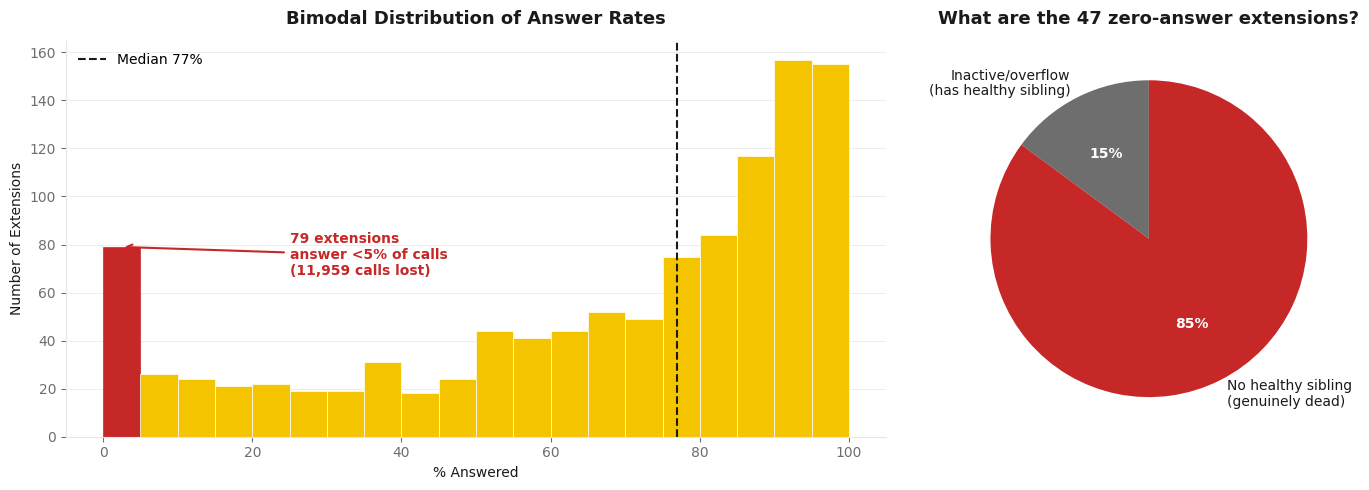

In [9]:
# --- Visual: histogram with the 0% spike annotated ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [2, 1]})

# Left: annotated histogram
bins = np.arange(0, 105, 5)
counts, edges, patches = ax1.hist(df_filtered['pct_answered'], bins=bins,
                                   color=HERTZ_YELLOW, edgecolor='white', linewidth=0.5)
for patch, left_edge in zip(patches, edges[:-1]):
    if left_edge < 5:
        patch.set_facecolor(NEG_RED)
        patch.set_edgecolor(NEG_RED)

ax1.annotate(f'{int(counts[0])} extensions\nanswer <5% of calls\n({zero_ext["Received Calls"].sum():,} calls lost)',
             xy=(2.5, counts[0]), xytext=(25, counts[0] * 0.85),
             fontsize=10, color=NEG_RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=NEG_RED, lw=1.5))

median_val = df_filtered['pct_answered'].median()
ax1.axvline(median_val, color=CHARCOAL, linewidth=1.5, linestyle='--', label=f'Median {median_val:.0f}%')
ax1.set_xlabel('% Answered', color=CHARCOAL)
ax1.set_ylabel('Number of Extensions', color=CHARCOAL)
ax1.set_title('Bimodal Distribution of Answer Rates',
              fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)
ax1.legend(frameon=False, fontsize=10)
ax1.grid(axis='y', color=LIGHT_GRAY, linewidth=0.5)
ax1.set_axisbelow(True)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
ax1.tick_params(colors=DARK_GRAY)

# Right: what are the 0% extensions?
labels = [f'Inactive/overflow\n(has healthy sibling)', f'No healthy sibling\n(genuinely dead)']
sizes_pie = [n_with, n_without]
colors_pie = [DARK_GRAY, NEG_RED]
wedges, texts, autotexts = ax2.pie(
    sizes_pie, labels=labels, colors=colors_pie, autopct='%1.0f%%',
    startangle=90, textprops={'fontsize': 10, 'color': CHARCOAL})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
ax2.set_title(f'What are the {len(zero_ext)} zero-answer extensions?',
              fontsize=13, fontweight='bold', color=CHARCOAL, pad=12)

for ax in [ax1, ax2]:
    ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

In [10]:
# --- Impact: what happens if we fix/redirect the 0% extensions? ---
zero_calls_lost = zero_ext['Received Calls'].sum()
low5_calls_lost = low_group['Unanswered Calls'].sum() if 'Unanswered Calls' in low_group.columns else low_group['Received Calls'].sum() - low_group['Answered Calls'].sum()

# Recalculate overall answer rate if 0% extensions were redirected
hypothetical_answered = total_answered + zero_calls_lost
hypothetical_pct = hypothetical_answered / total_received * 100

print('=' * 60)
print('  IMPACT ANALYSIS: What if 0%-answer extensions were fixed?')
print('=' * 60)
print(f'  Calls currently lost to 0% extensions:  {zero_calls_lost:>8,}')
print(f'  That is {zero_calls_lost/total_received*100:.1f}% of all received calls')
print()
print(f'  Current overall % answered:              {total_answered/total_received*100:.1f}%')
print(f'  If 0% extensions were redirected:        {hypothetical_pct:.1f}%')
print(f'  Uplift:                                  +{hypothetical_pct - total_answered/total_received*100:.1f}pp')
print('=' * 60)
print()
print('Biggest 0%-answer extensions by volume (quick wins):')
print(f'{"Extension":<35s} {"Received":>10s}')
print('-' * 47)
for _, r in zero_ext.nlargest(10, 'Received Calls').iterrows():
    print(f'{r["Department"]:<35s} {int(r["Received Calls"]):>10,}')

  IMPACT ANALYSIS: What if 0%-answer extensions were fixed?
  Calls currently lost to 0% extensions:    11,959
  That is 6.4% of all received calls

  Current overall % answered:              60.6%
  If 0% extensions were redirected:        67.1%
  Uplift:                                  +6.4pp

Biggest 0%-answer extensions by volume (quick wins):
Extension                             Received
-----------------------------------------------
houstonhobbydtg74336                     7,468
ftmyresregion133211                        888
gulffreeway766024                          349
jfkintlap190310                            323
clintt543012                               293
despl536020                                276
downtownmon805010                          198
sford132512                                190
sherat223522                               163
charlotte685814                            129


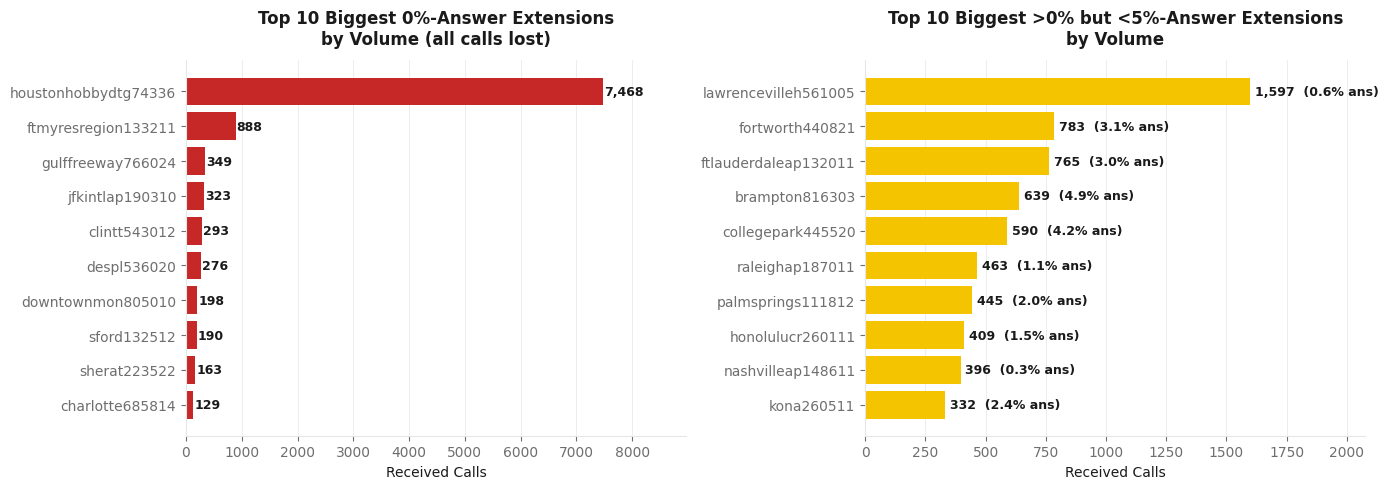

In [11]:
# --- Top 10 by volume: 0% vs non-zero (but <5%) answer extensions ---
top10_zero = zero_ext.nlargest(10, 'Received Calls').sort_values('Received Calls')
nonzero_low = df_filtered[(df_filtered['pct_answered'] > 0) & (df_filtered['pct_answered'] < 5)]
top10_nonzero_low = nonzero_low.nlargest(10, 'Received Calls').sort_values('Received Calls')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: 0% answer extensions
bars1 = ax1.barh(top10_zero['Department'], top10_zero['Received Calls'], color=NEG_RED)
for bar, (_, row) in zip(bars1, top10_zero.iterrows()):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f'{int(row["Received Calls"]):,}',
             va='center', ha='left', fontsize=9, color=CHARCOAL, fontweight='bold')

ax1.set_xlabel('Received Calls', color=CHARCOAL)
ax1.set_title('Top 10 Biggest 0%-Answer Extensions\nby Volume (all calls lost)',
              fontsize=12, fontweight='bold', color=CHARCOAL, pad=12)
ax1.set_xlim(0, top10_zero['Received Calls'].max() * 1.2)

# Right: non-zero but <5% answer extensions
bars2 = ax2.barh(top10_nonzero_low['Department'], top10_nonzero_low['Received Calls'], color=HERTZ_YELLOW)
for bar, (_, row) in zip(bars2, top10_nonzero_low.iterrows()):
    ax2.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
             f'{int(row["Received Calls"]):,}  ({row["pct_answered"]:.1f}% ans)',
             va='center', ha='left', fontsize=9, color=CHARCOAL, fontweight='bold')

ax2.set_xlabel('Received Calls', color=CHARCOAL)
ax2.set_title('Top 10 Biggest >0% but <5%-Answer Extensions\nby Volume',
              fontsize=12, fontweight='bold', color=CHARCOAL, pad=12)
ax2.set_xlim(0, top10_nonzero_low['Received Calls'].max() * 1.3)

for ax in [ax1, ax2]:
    ax.grid(axis='x', color=LIGHT_GRAY, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['bottom', 'left']].set_color(LIGHT_GRAY)
    ax.tick_params(colors=DARK_GRAY)
    ax.set_facecolor('white')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()